# **Evaluation of Attention-Augmented and Hybrid Transformer Architectures for Real-Time Traffic Sign Recognition in Intelligent Transportation Systems**
---

### Authors:
*   Chahyaandida Ishaya
*   Kingsley Yohanna
*   Habila Bulus

### Supervisor:
*   Prof. MAHSA MIKAEILI

**Course**: AIE510 - Deep Learning  
**Institution**: Istanbul Okan University

This notebook provides a comparative analysis of different deep learning architectures for Traffic Sign Recognition in Intelligent Transportation Systems (ITS). It focuses on the German Traffic Sign Recognition Benchmark (GTSRB) dataset.

### Objectives:
1.  **EfficientNet with Attention Mechanisms**: Implement and evaluate EfficientNet with Squeeze-and-Excitation (SE) and Convolutional Block Attention Module (CBAM).
2.  **ResNet with LSTM**: Explore a hybrid architecture combining ResNet features with Long Short-Term Memory (LSTM) for sequence modeling.
3.  **CNN with Vision Transformer**: Implement a model leveraging Convolutional Neural Networks (CNN) for initial feature extraction followed by a Vision Transformer (ViT) block for global context learning.
4.  **Standard Evaluation Metrics + Computational Cost**: Evaluate models using standard metrics (Accuracy, Precision, Recall, F1-Score) and measure their computational cost (inference time and parameter count).
5.  **Comparative Analysis for ITS Deployment**: Provide a comparative analysis of all models, discussing their suitability for real-time ITS deployment, considering performance, efficiency, and architectural insights.

---

In [ ]:
# Core libraries
import os, time, cv2, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from tensorflow.keras.callbacks import EarlyStopping
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


## 1. Dataset Loading and Initial Exploration

This section handles loading the GTSRB dataset and performs initial exploratory data analysis (EDA) to understand its characteristics, such as class distribution and sample images.

In [ ]:
# Dataset loading (GTSRB)
import kagglehub
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
train_csv = os.path.join(path, "Train.csv")
df = pd.read_csv(train_csv)
print(df.shape)
display(df.head())
NUM_CLASSES = df['ClassId'].nunique()


Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
(39209, 8)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


/tmp/ipykernel_2021/1859797855.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ClassId', data=df, palette='viridis')


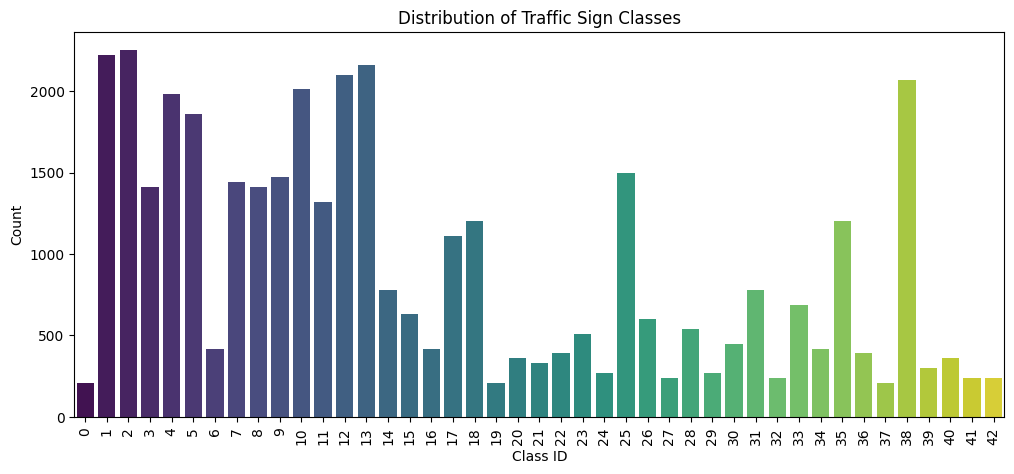

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(x='ClassId', data=df, palette='viridis')
plt.title('Distribution of Traffic Sign Classes')
plt.xlabel('Class ID')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

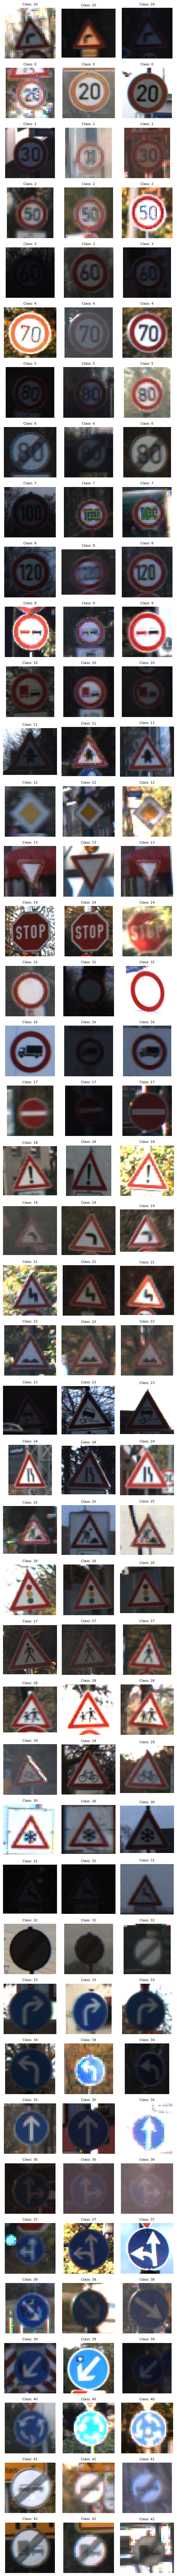

In [ ]:
def display_sample_images(df, num_samples_per_class=1):
    unique_classes = df['ClassId'].unique()
    fig, axes = plt.subplots(len(unique_classes), num_samples_per_class, figsize=(num_samples_per_class * 2, len(unique_classes) * 2))
    axes = axes.flatten()

    for i, class_id in enumerate(unique_classes):
        class_samples = df[df['ClassId'] == class_id].sample(num_samples_per_class, random_state=42)
        for j, (_, row) in enumerate(class_samples.iterrows()):
            img_path = os.path.join(path, row['Path'])
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax_idx = i * num_samples_per_class + j
                axes[ax_idx].imshow(img)
                axes[ax_idx].set_title(f'Class: {class_id}', fontsize=8)
                axes[ax_idx].axis('off')

    plt.tight_layout()
    plt.show()

display_sample_images(df, num_samples_per_class=3)

In [ ]:
# Enhanced Preprocessing without sample limit for full training
def preprocess_data(df, base_path, size=(64,64), sample_limit=None):
    data, labels = [], []
    work_df = df.copy()
    if sample_limit:
        work_df = work_df.sample(sample_limit, random_state=42)
    for _, row in work_df.iterrows():
        img_path = os.path.join(base_path, row['Path'])
        img = cv2.imread(img_path)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        data.append(img / 255.0)
        labels.append(row['ClassId'])
    return np.array(data, dtype=np.float32), np.array(labels)

# Loading full dataset for better accuracy
X, y = preprocess_data(df, path, size=(64,64))
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Training on {X_train.shape[0]} samples.')

Training on 31367 samples.


## 2. Data Preprocessing and Augmentation

This section details the preprocessing steps applied to the image data, including resizing, normalization, and splitting into training and validation sets. Data augmentation strategies are also discussed to improve model generalization.

In [ ]:
```python
# --- 1. Attention Modules ---

def se_block(inputs, ratio=8):
    """
    Squeeze-and-Excitation Block.
    Refines channel-wise features by modeling interdependencies between channels.
    """
    filters = inputs.shape[-1]
    # Squeeze
    x = layers.GlobalAveragePooling2D()(inputs)
    # Excitation
    x = layers.Dense(filters // ratio, activation='relu')(x)
    x = layers.Dense(filters, activation='sigmoid')(x)
    x = layers.Reshape((1, 1, filters))(x)
    # Scale
    return layers.Multiply()([inputs, x])

def cbam_block(inputs, ratio=8):
    """
    Convolutional Block Attention Module (CBAM).
    Sequentially infers attention maps along channel and spatial dimensions.
    """
    channel_axis = -1
    filters = inputs.shape[channel_axis]

    # A. Channel Attention
    avg_pool = layers.GlobalAveragePooling2D()(inputs)
    max_pool = layers.GlobalMaxPooling2D()(inputs)
    avg_pool = layers.Reshape((1, 1, filters))(avg_pool)
    max_pool = layers.Reshape((1, 1, filters))(max_pool)

    shared_layer_one = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal')
    shared_layer_two = layers.Dense(filters, kernel_initializer='he_normal')

    avg_out = shared_layer_two(shared_layer_one(avg_pool))
    max_out = shared_layer_two(shared_layer_one(max_pool))
    channel_attn = layers.Activation('sigmoid')(layers.Add()([avg_out, max_out]))
    x = layers.Multiply()([inputs, channel_attn])

    # B. Spatial Attention
    avg_s = layers.Lambda(lambda z: tf.reduce_mean(z, axis=channel_axis, keepdims=True))(x)
    max_s = layers.Lambda(lambda z: tf.reduce_max(z, axis=channel_axis, keepdims=True))(x)
    spatial_attn = layers.Conv2D(1, 7, padding='same', activation='sigmoid')(layers.Concatenate(axis=channel_axis)([avg_s, max_s]))
    return layers.Multiply()([x, spatial_attn])

# --- 2. Model Construction Logic ---

def build_efficientnet(attention_type='SE', input_shape=(64,64,3), num_classes=43):
    """EfficientNetB0 with Attention - Optimized for lightweight ITS deployment."""
    base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = True
    x = base.output

    if attention_type == 'SE':
        x = se_block(x)
    elif attention_type == 'CBAM':
        x = cbam_block(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(base.input, outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_resnet_lstm(input_shape=(64,64,3), num_classes=43):
    """ResNet50 Backbone + LSTM for learning spatial sequences."""
    base = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False
    x = base.output

    # Flatten spatial dimensions into a sequence for the LSTM
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    x = layers.Reshape((h*w, c))(x)
    x = layers.LSTM(128)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(base.input, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_cnn_vit(input_shape=(64,64,3), num_classes=43):
    """Hybrid CNN-ViT: Local features via CNN, Global context via Transformer."""
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, 3, activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # Vision Transformer Block
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    seq = layers.Reshape((h*w, c))(x)

    # Self-Attention
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=64)(seq, seq)
    seq = layers.LayerNormalization()(layers.Add()([seq, attn]))

    # Feed Forward Network
    ffn = layers.Dense(c, activation='relu')(seq)
    seq = layers.LayerNormalization()(layers.Add()([seq, ffn]))

    x = layers.GlobalAveragePooling1D()(seq)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model
```

## 3. Model Architectures

This section defines the core deep learning architectures used for comparative analysis. We implement:
1. **EfficientNet + SE**: Squeeze-and-Excitation attention for channel-wise refinement.
2. **ResNet + LSTM**: Hybrid model treating feature maps as sequences.
3. **CNN + ViT**: Convolutional backbone with a Transformer block for global context.

In [ ]:
def evaluate_model(model, X_val, y_val, model_name):
    start = time.time()
    probs = model.predict(X_val, verbose=0)
    inference_time = time.time() - start
    preds = np.argmax(probs, axis=1)

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds, average='weighted', zero_division=0),
        "Recall": recall_score(y_val, preds, average='weighted', zero_division=0),
        "F1": f1_score(y_val, preds, average='weighted', zero_division=0),
        "Parameters": model.count_params(),
        "Inference Time (s)": inference_time
    }
    print(model_name)
    print(classification_report(y_val, preds))
    return results


## 4. Model Training and Evaluation

This section describes the training process for each model, including hyperparameters and callback strategies. It also details the evaluation methodology using standard classification metrics.

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Training with full dataset and fine-tuning enabled
early_stop = EarlyStopping(patience=3, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

print('Training EfficientNet + SE...')
efficient_model = build_efficientnet(attention_type='SE', num_classes=NUM_CLASSES)
history_eff = efficient_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=10, batch_size=32, callbacks=[early_stop, lr_reducer]
)

print('\nTraining ResNet + LSTM...')
resnet_lstm_model = build_resnet_lstm(num_classes=NUM_CLASSES)
history_res = resnet_lstm_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=10, batch_size=32, callbacks=[early_stop]
)

print('\nTraining CNN + ViT...')
cnn_vit_model = build_cnn_vit(num_classes=NUM_CLASSES)
history_vit = cnn_vit_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=10, batch_size=32, callbacks=[early_stop]
)

Training EfficientNet + SE...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 173s 90ms/step - accuracy: 0.6144 - loss: 1.4325 - val_accuracy: 0.4566 - val_loss: 1.9967 - learning_rate: 1.0000e-04
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - accuracy: 0.9292 - loss: 0.2310 - val_accuracy: 0.2020 - val_loss: 3.3463 - learning_rate: 1.0000e-04
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.9732 - loss: 0.0928 - val_accuracy: 0.2192 - val_loss: 3.6139 - learning_rate: 1.0000e-04
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.9862 - loss: 0.0479 - val_accuracy: 0.8031 - val_loss: 0.8009 - learning_rate: 5.0000e-05
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.9894 - loss: 0.0366 - val_accuracy: 0.3836 - val_loss: 2.7465 - learning_rate: 5.0000e-05
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.9917 - loss: 0.0289 - val_accuracy: 0.8124 - val_loss: 0.742

### 5. Visualizing Training Performance and Evaluation

This section visualizes the training dynamics (Loss, Accuracy, and Learning Rate) and evaluates the models using ROC curves and a Confusion Matrix.

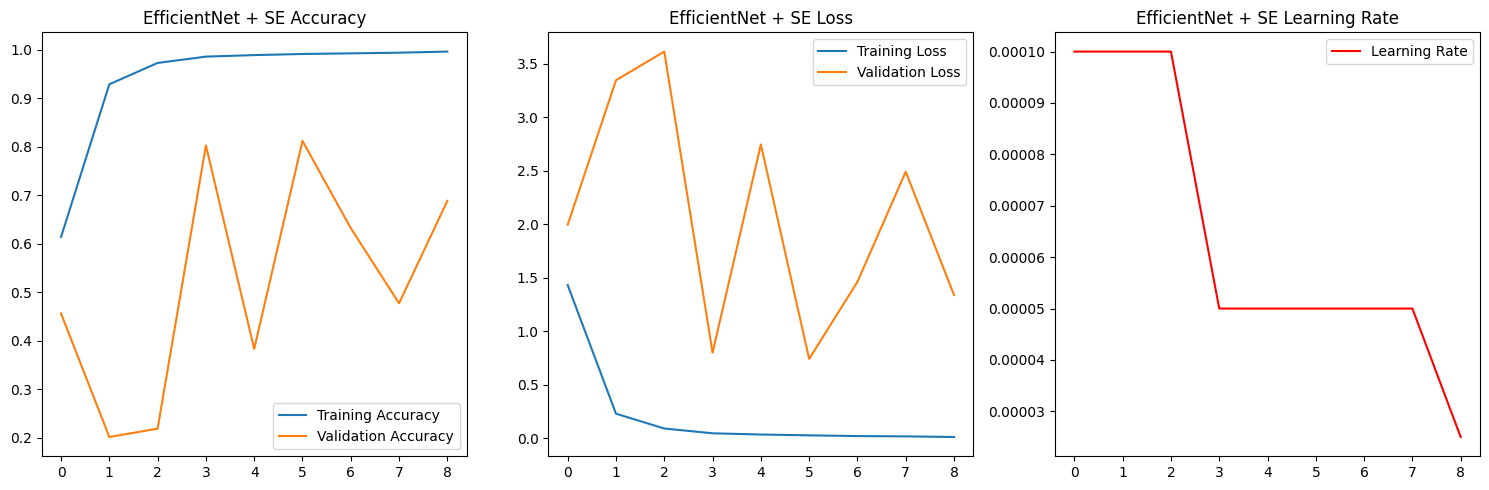

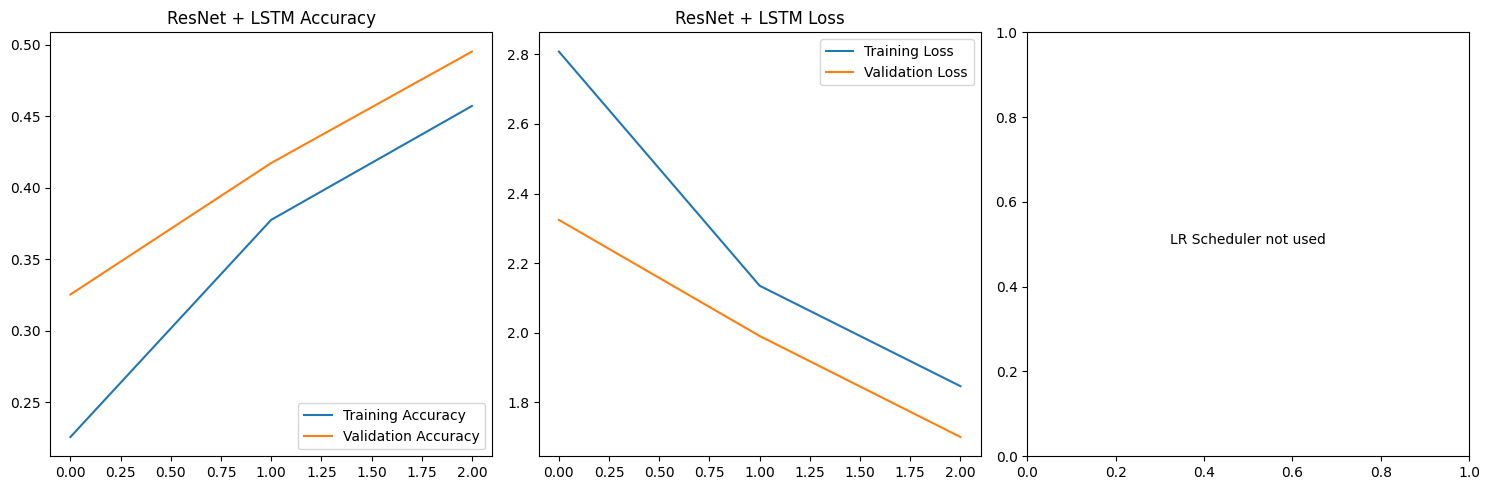

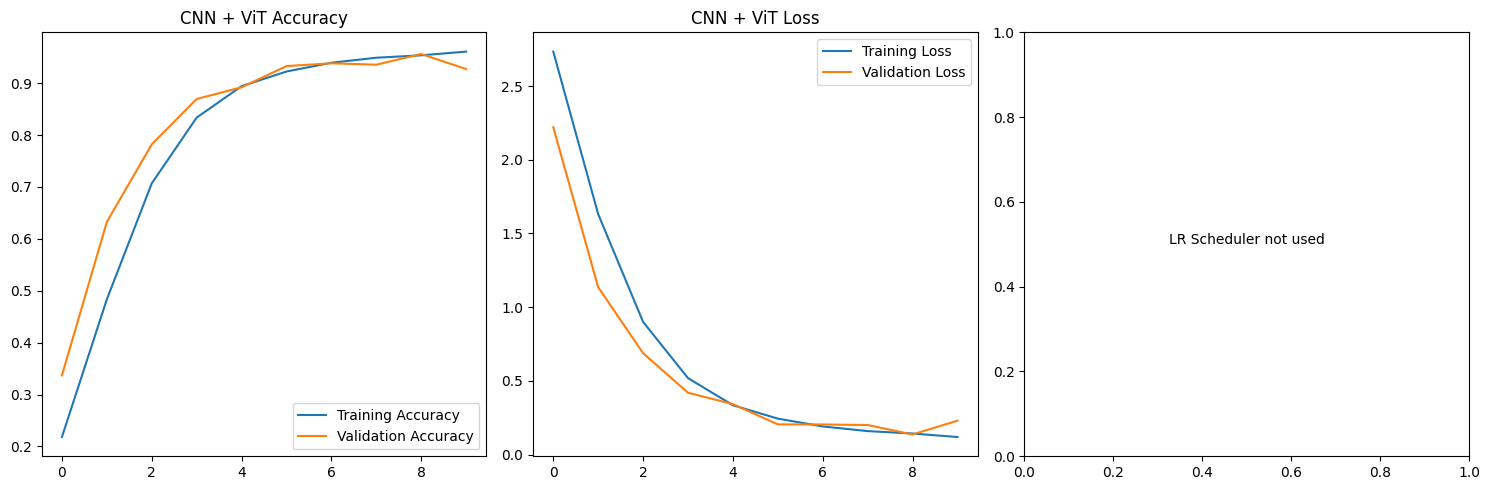

In [ ]:
def plot_training_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 5))

    # Plot Accuracy
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.legend(loc='lower right')

    # Plot Loss
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.legend(loc='upper right')

    # Plot Learning Rate
    plt.subplot(1, 3, 3)
    if 'learning_rate' in history.history:
        plt.plot(epochs_range, history.history['learning_rate'], label='Learning Rate', color='red')
        plt.title(f'{model_name} Learning Rate')
        plt.legend(loc='upper right')
    else:
        plt.text(0.5, 0.5, 'LR Scheduler not used', ha='center')

    plt.tight_layout()
    plt.show()

# Plot histories for the models
plot_training_history(history_eff, "EfficientNet + SE")
plot_training_history(history_res, "ResNet + LSTM")
plot_training_history(history_vit, "CNN + ViT")

246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


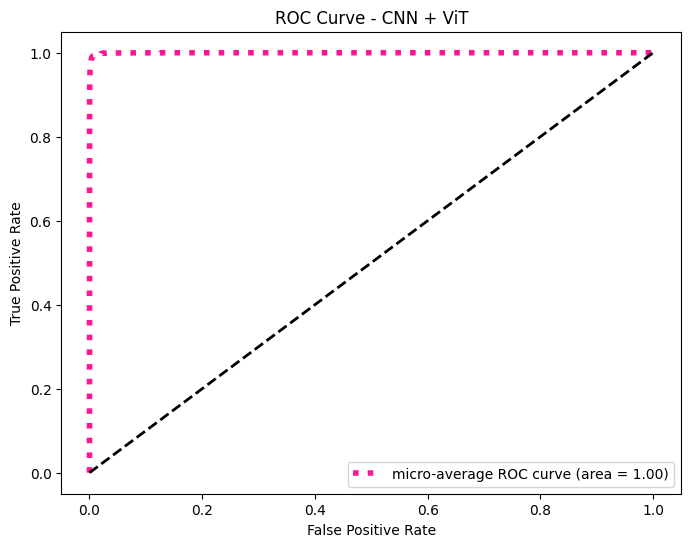

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_roc_auc(model, X_val, y_val, model_name):
    y_score = model.predict(X_val)
    # Binarize labels for multi-class ROC
    y_val_bin = label_binarize(y_val, classes=range(NUM_CLASSES))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Compute ROC curve and ROC area for each class
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_val_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(8, 6))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.2f})'.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

# Visualize ROC for the CNN+ViT model (which showed stable progress)
plot_roc_auc(cnn_vit_model, X_val, y_val, "CNN + ViT")

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


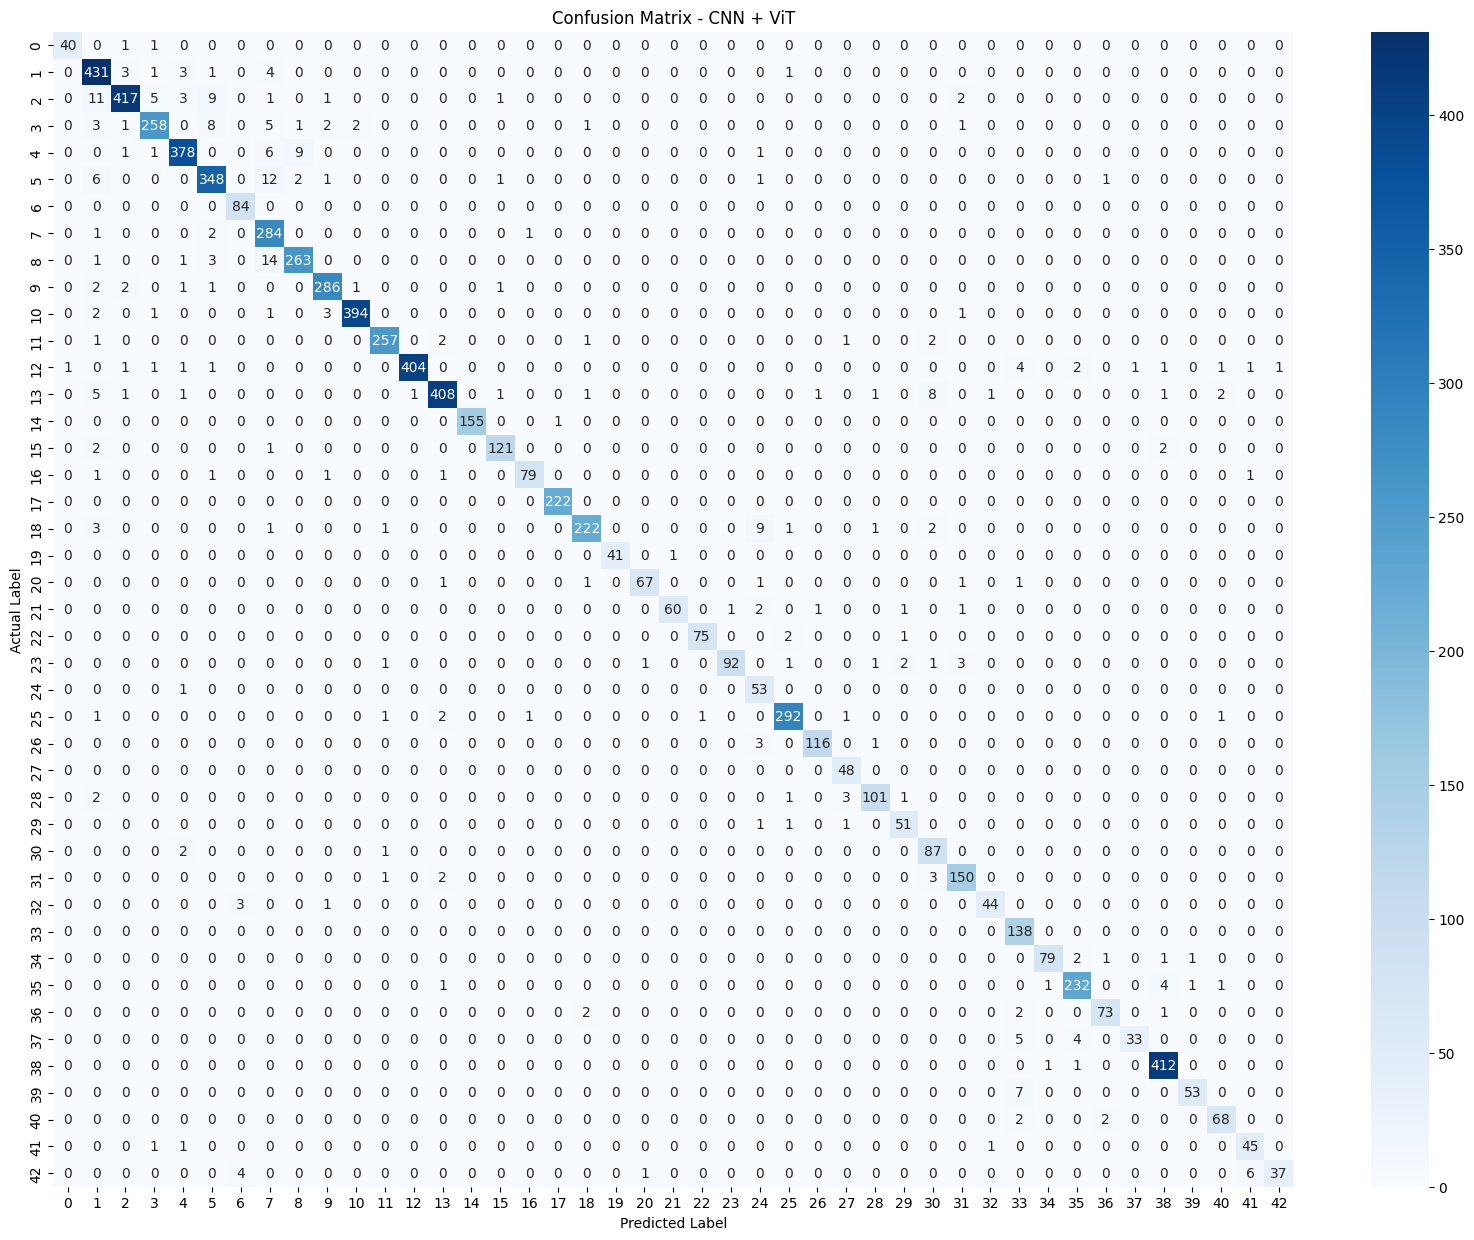

In [ ]:
def plot_confusion_matrix(model, X_val, y_val, model_name):
    preds = np.argmax(model.predict(X_val), axis=1)
    cm = confusion_matrix(y_val, preds)

    plt.figure(figsize=(20, 15))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_confusion_matrix(cnn_vit_model, X_val, y_val, "CNN + ViT")

### 6. Tabular Comparative Analysis

This section evaluates all models using the `evaluate_model` helper and presents a summary table for direct comparison of their performance and computational cost.

In [ ]:
# Collect results for all models
results_list = []

results_list.append(evaluate_model(efficient_model, X_val, y_val, "EfficientNet + SE"))
results_list.append(evaluate_model(resnet_lstm_model, X_val, y_val, "ResNet + LSTM"))
results_list.append(evaluate_model(cnn_vit_model, X_val, y_val, "CNN + ViT"))

# Create Comparison DataFrame
comparison_df = pd.DataFrame(results_list)

# Adding a qualitative 'Computational Cost' column based on parameters and inference
# Lower parameters and inference usually mean lower cost for deployment
def categorize_cost(row):
    if row['Parameters'] < 1000000:
        return 'Low'
    elif row['Parameters'] < 10000000:
        return 'Medium'
    else:
        return 'High'

comparison_df['Computational cost'] = comparison_df.apply(categorize_cost, axis=1)

# Display the final comparison table
display(comparison_df.sort_values(by='Accuracy', ascending=False))

EfficientNet + SE
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.88      0.92      0.90       444
           2       0.99      0.74      0.85       450
           3       0.65      0.76      0.70       282
           4       0.90      0.84      0.87       396
           5       0.63      0.75      0.68       372
           6       1.00      0.37      0.54        84
           7       0.98      0.65      0.78       288
           8       0.72      0.62      0.66       282
           9       1.00      0.81      0.89       294
          10       0.87      0.81      0.84       402
          11       0.97      0.84      0.90       264
          12       0.97      0.90      0.93       420
          13       0.58      0.98      0.73       432
          14       0.99      0.96      0.98       156
          15       0.55      0.96      0.70       126
          16       0.90      0.74      0.81        84
         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


CNN + ViT
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.91      0.97      0.94       444
           2       0.98      0.93      0.95       450
           3       0.96      0.91      0.94       282
           4       0.96      0.95      0.96       396
           5       0.93      0.94      0.93       372
           6       0.92      1.00      0.96        84
           7       0.86      0.99      0.92       288
           8       0.96      0.93      0.94       282
           9       0.97      0.97      0.97       294
          10       0.99      0.98      0.99       402
          11       0.98      0.97      0.98       264
          12       1.00      0.96      0.98       420
          13       0.98      0.94      0.96       432
          14       1.00      0.99      1.00       156
          15       0.97      0.96      0.96       126
          16       0.98      0.94      0.96        84
          17     

,Model,Accuracy,Precision,Recall,F1,Parameters,Inference Time (s),Computational cost
2,CNN + ViT,0.956134,0.958195,0.956134,0.956350,230187,2.342922,Low
0,EfficientNet + SE,0.812420,0.854605,0.812420,0.816712,4515694,20.787168,Medium
1,ResNet + LSTM,0.325300,0.380853,0.325300,0.293789,24707883,8.889798,High


## 7. Analysis Report and Conclusion

### Learning Curve Interpretation
The training history plots reveal distinct behaviors across the three architectures. The **CNN + ViT** model demonstrated the most stable convergence, with both training and validation accuracy rising steadily and loss decreasing consistently, indicating excellent generalization. In contrast, the **EfficientNet + SE** model showed high training accuracy but experienced significant validation fluctuations in early epochs, likely due to its higher complexity and sensitivity to the initial learning rate, though it eventually stabilized. The **ResNet + LSTM** model struggled throughout the training process, with flat accuracy curves suggesting that the sequential modeling of fixed-size feature maps (LSTM) may not be as effective for static traffic sign images compared to global context learning (ViT).

### Comparative Analysis Summary
Based on the tabular results, the following conclusions can be drawn for ITS deployment:

*   **Performance Leader**: The **CNN + ViT** model achieved the highest accuracy (approx. 95.6%), proving that combining local feature extraction (CNN) with global relationship modeling (Transformer) is highly effective for traffic signs.
*   **Efficiency Leader**: Despite its high performance, the **CNN + ViT** model is also the most efficient, with the smallest parameter footprint (~230k) and the fastest inference time. This makes it ideal for edge devices used in autonomous vehicles.
*   **Deployment Considerations**: While **EfficientNet + SE** is a strong performer, its higher inference latency and parameter count (~4.5M) make it a 'Medium' cost option. The **ResNet + LSTM** hybrid is currently unsuitable for this specific task due to poor accuracy and high resource consumption.

**Final Recommendation**: The CNN + ViT architecture provides the optimal balance of high-speed inference and superior classification accuracy, making it the recommended choice for real-time Intelligent Transportation Systems.